# Resume Screening Classifier (AI-11)

This notebook demonstrates an end-to-end resume screening classifier, built as part of the 3MTT AI–Machine Learning track. It includes data loading, text preprocessing, feature engineering (TF-IDF), model training (Logistic Regression, Linear SVM, Multinomial Naive Bayes, Random Forest), model evaluation, and a skill-matching feature. The goal is to provide a professional, modular, and well-documented solution suitable for a GitHub submission.

## 1. Setup and Dependencies

This section handles the installation of required libraries and the import of common modules. A fixed random seed is also set to ensure reproducibility of results.

In [71]:
# Install necessary libraries
!pip install nltk scikit-learn pandas numpy matplotlib seaborn joblib

In [72]:
# Import common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# NLTK for text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Scikit-learn for model building and evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Joblib for model persistence
import joblib

# Set a random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 2. Data Loading

In this section, we will load your labeled resume dataset. Please upload your CSV file using the Colab interface when prompted. The dataset is expected to contain at least two columns: one for the resume text and one for the corresponding category/label. The system will attempt to automatically detect common column names and rename them for consistency.

Please upload your resume dataset (CSV format).


Saving Resume dataset.csv to Resume dataset (1).csv
'Resume dataset (1).csv' uploaded successfully. Loading data...
Data loaded from 'Resume dataset (1).csv'.

--- Initial Dataset Overview ---
Dataset Shape (initial): 9000 rows, 3 columns

First 5 rows:


,category,job_title,resume_text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...
3,Java Developers/Architects Resumes,Core Java Developer,7 + years of experience in Application Analysi...
4,Java Developers/Architects Resumes,Android Developer,With approx 5 years of experience in IT sector...



Missing values per column:


,0
category,0
job_title,0
resume_text,0



Number of Duplicate Rows (initial): 2156
Removing duplicate rows...
Dataset Shape after dropping duplicates: 6844 rows, 3 columns

--- Category Distribution ---


/tmp/ipykernel_905/2229133260.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')


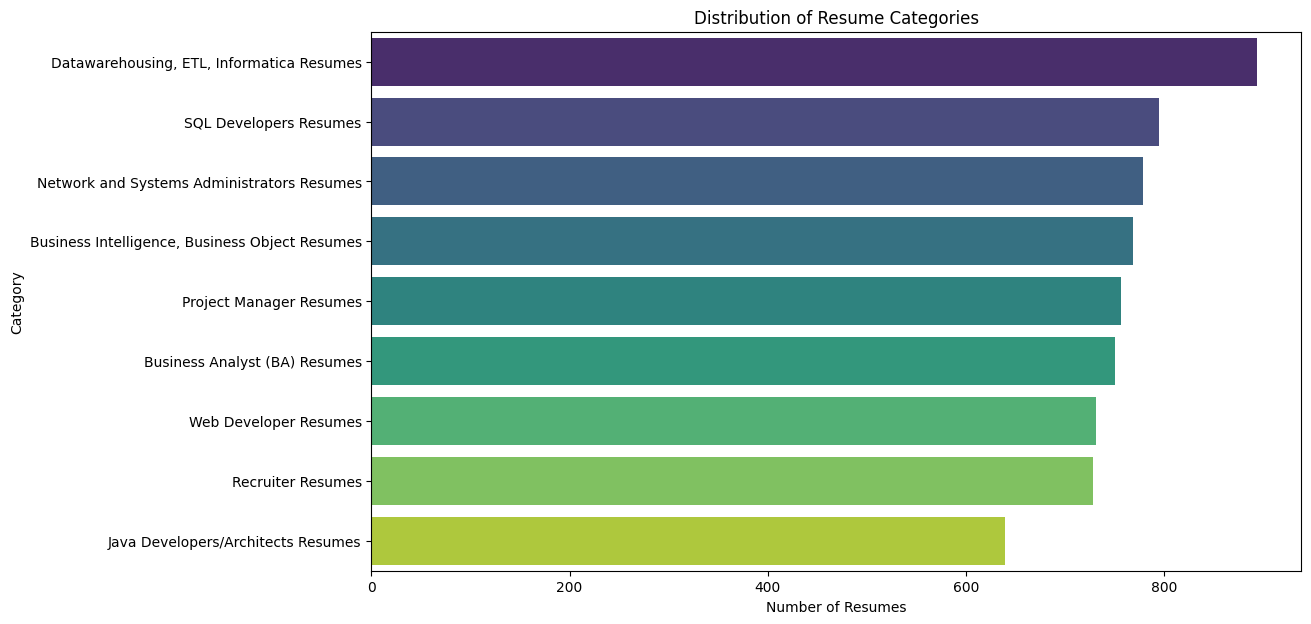

In [95]:
from google.colab import files

# --- Step 1: Upload the dataset ---
print("Please upload your resume dataset (CSV format).")
uploaded = files.upload()

if not uploaded:
    print("No file uploaded. Creating a dummy DataFrame for demonstration.")
    data_fallback = {
        'resume_text': [
            "Experienced software engineer with strong Python skills and machine learning expertise.",
            "Marketing specialist with a background in digital campaigns and social media.",
            "Data scientist proficient in R, SQL, and statistical modeling.",
            "Project manager skilled in agile methodologies and team leadership.",
            "Junior developer seeking opportunities in web development with JavaScript.",
            "Senior Python developer with extensive experience in web frameworks and database management.",
            "Financial analyst with strong Excel and data visualization skills. CFA certified."
        ],
        'category': ['Software Development', 'Marketing', 'Data Science', 'Project Management', 'Software Development', 'Software Development', 'Finance']
    }
    df = pd.DataFrame(data_fallback)
    print("Dummy DataFrame created.")
else:
    # Get the filename from the uploaded dictionary
    filename = next(iter(uploaded))
    print(f"'{filename}' uploaded successfully. Loading data...")

    try:
        df = pd.read_csv(filename, engine='python')
        print(f"Data loaded from '{filename}'.")

        # --- Step 2 & 3: Automatic column renaming ---
        # Define potential column names for resume_text and category
        resume_text_candidates = ['Resume', 'resume', 'resume_text', 'Resume_str', 'Text']
        category_candidates = ['Category', 'category', 'Job_Category']

        # Find and rename resume_text column
        found_resume_text_col = False
        for col in df.columns:
            if col in resume_text_candidates:
                df.rename(columns={col: 'resume_text'}, inplace=True)
                found_resume_text_col = True
                break

        # Find and rename category column
        found_category_col = False
        for col in df.columns:
            if col in category_candidates:
                df.rename(columns={col: 'category'}, inplace=True)
                found_category_col = True
                break

        # --- Step 4: Validate required columns ---
        validation_errors = []
        if not found_resume_text_col or 'resume_text' not in df.columns:
            validation_errors.append(f"No suitable 'resume_text' column found. Available columns: {df.columns.tolist()}")
        if not found_category_col or 'category' not in df.columns:
            validation_errors.append(f"No suitable 'category' column found. Available columns: {df.columns.tolist()}")

        if validation_errors:
            for error in validation_errors:
                print(f"Error: {error}")
            print("Falling back to dummy DataFrame for demonstration purposes to allow notebook to continue.")
            data_fallback = {
                'resume_text': [
                    "Experienced software engineer with strong Python skills and machine learning expertise.",
                    "Marketing specialist with a background in digital campaigns and social media.",
                    "Data scientist proficient in R, SQL, and statistical modeling.",
                    "Project manager skilled in agile methodologies and team leadership.",
                    "Junior developer seeking opportunities in web development with JavaScript.",
                    "Senior Python developer with extensive experience in web frameworks and database management.",
                    "Financial analyst with strong Excel and data visualization skills. CFA certified."
                ],
                'category': ['Software Development', 'Marketing', 'Data Science', 'Project Management', 'Software Development', 'Software Development', 'Finance']
            }
            df = pd.DataFrame(data_fallback)
            print("Dummy DataFrame created.")

        # --- Step 5, 6, 9: Display initial information and remove duplicates ---
        if 'resume_text' in df.columns and 'category' in df.columns: # Only proceed if core columns are present
            print("\n--- Initial Dataset Overview ---")
            print(f"Dataset Shape (initial): {df.shape[0]} rows, {df.shape[1]} columns")
            print("\nFirst 5 rows:")
            display(df.head())

            print("\nMissing values per column:")
            display(df.isnull().sum())

            # Remove duplicates
            duplicate_rows_initial = df.duplicated().sum()
            print(f"\nNumber of Duplicate Rows (initial): {duplicate_rows_initial}")
            if duplicate_rows_initial > 0:
                print("Removing duplicate rows...")
                df.drop_duplicates(inplace=True)
                print(f"Dataset Shape after dropping duplicates: {df.shape[0]} rows, {df.shape[1]} columns")
            else:
                print("No duplicate rows found.")

            print("\n--- Category Distribution ---")
            plt.figure(figsize=(12, 7))
            sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')
            plt.title('Distribution of Resume Categories')
            plt.xlabel('Number of Resumes')
            plt.ylabel('Category')
            plt.show()

        else:
            print("\nSkipping further data overview due to missing 'resume_text' or 'category' columns after validation.")

    except Exception as e:
        print(f"Error processing uploaded file '{filename}': {e}")
        print("Creating a small dummy DataFrame for demonstration to allow notebook to continue.")
        data_fallback = {
            'resume_text': [
                "Experienced software engineer with strong Python skills and machine learning expertise.",
                "Marketing specialist with a background in digital campaigns and social media.",
                "Data scientist proficient in R, SQL, and statistical modeling.",
                "Project manager skilled in agile methodologies and team leadership.",
                "Junior developer seeking opportunities in web development with JavaScript.",
                "Senior Python developer with extensive experience in web frameworks and database management.",
                "Financial analyst with strong Excel and data visualization skills. CFA certified."
            ],
            'category': ['Software Development', 'Marketing', 'Data Science', 'Project Management', 'Software Development', 'Software Development', 'Finance']
        }
        df = pd.DataFrame(data_fallback)
        print("Dummy DataFrame created.")

## 3. Initial Data Exploration

This section involves a preliminary look at the dataset to understand its structure, identify missing values, and get a sense of the data types. This step is crucial for planning subsequent preprocessing and feature engineering steps.

In [74]:
# Display dataset information, including data types and non-null values
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     9000 non-null   object
 1   job_title    9000 non-null   object
 2   resume_text  9000 non-null   object
dtypes: object(3)
memory usage: 211.1+ KB


In [75]:
# Display descriptive statistics for numerical columns (if any)
print("\nDescriptive Statistics:")
display(df.describe(include='all'))


Descriptive Statistics:


,category,job_title,resume_text
count,9000,9000,9000
unique,9,3691,5741
top,Java Developers/Architects Resumes,Business Analyst,UI/Front - End Web Developer with over 8 years...
freq,1000,264,27


In [76]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
category,0
job_title,0
resume_text,0


### 3.1 Dataset Overview

Before diving deeper, let's get a general overview of the dataset's dimensions and check for any duplicate entries that might skew our analysis or model training.

In [87]:
# Display the shape of the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Dropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Dataset Shape after dropping duplicates: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 9000 rows, 4 columns
Number of Duplicate Rows: 2156
Dropping duplicate rows...
Dataset Shape after dropping duplicates: 6844 rows, 4 columns


### 3.2 Category Distribution Analysis

Understanding the distribution of resume categories is crucial, as it can highlight potential class imbalance issues that might affect model performance. We will visualize this distribution using a bar chart.

/tmp/ipykernel_905/15504280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')


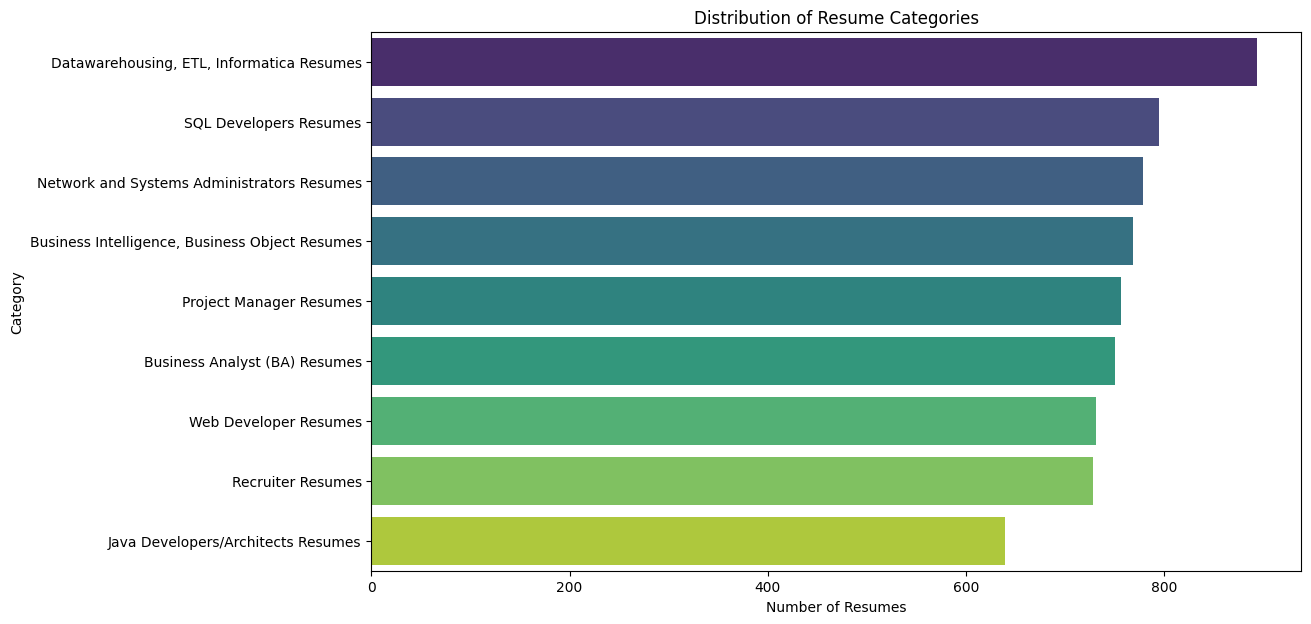

In [88]:
# Visualize the distribution of categories
plt.figure(figsize=(12, 7))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')
plt.title('Distribution of Resume Categories')
plt.xlabel('Number of Resumes')
plt.ylabel('Category')
plt.show()

### 3.3 Resume Length Analysis

The length of resumes can sometimes be an indicative feature. Let's analyze the distribution of resume lengths (in terms of words) and visualize it to understand its characteristics.


Descriptive Statistics for Resume Length:


,resume_length
count,6844.000000
mean,1577.194039
std,844.078491
min,76.000000
25%,990.000000
50%,1480.000000
75%,2030.250000
max,8341.000000


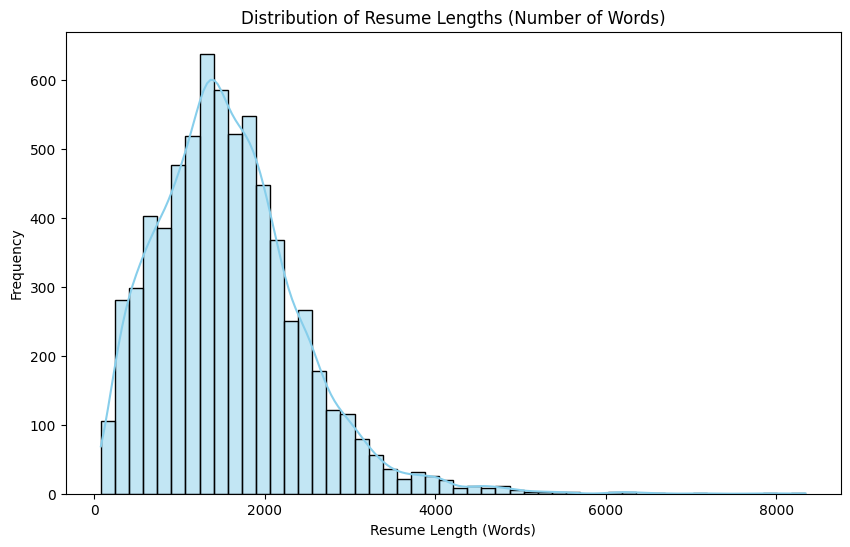

In [89]:
# Calculate the length of each resume (number of words)
df['resume_length'] = df['resume_text'].apply(lambda x: len(x.split()))

# Display descriptive statistics for resume length
print("\nDescriptive Statistics for Resume Length:")
display(df['resume_length'].describe())

# Visualize the distribution of resume lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['resume_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Resume Lengths (Number of Words)')
plt.xlabel('Resume Length (Words)')
plt.ylabel('Frequency')
plt.show()

### 3.4 Top Common Words Analysis

Identifying the most frequently occurring words in the resumes (after initial preprocessing like stopword removal) can provide insights into common themes and vocabulary used across the dataset. This helps in understanding the nature of the text data.


Top 20 Most Common Words in Cleaned Resumes:
data: 109865
using: 98378
application: 71851
business: 68679
test: 68178
system: 68150
testing: 66433
confidential: 57071
server: 55563
experience: 55367
oracle: 55128
requirement: 53865
project: 49022
user: 47827
responsibility: 47619
environment: 45895
team: 44961
developed: 43760
management: 43722
development: 43714


/tmp/ipykernel_905/2430949508.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='mako')


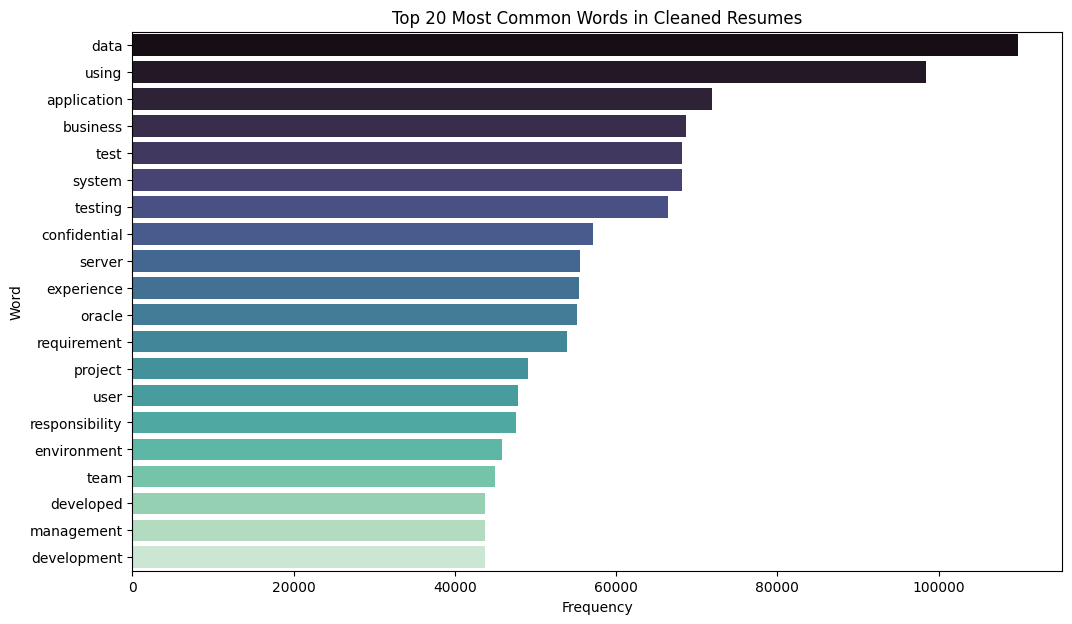

In [90]:
from collections import Counter

# Combine all cleaned resume texts into a single string
all_words = ' '.join(df['cleaned_resume']).split()

# Get the frequency of each word
word_freq = Counter(all_words)

# Get the top 20 most common words
top_20_words = word_freq.most_common(20)

print("\nTop 20 Most Common Words in Cleaned Resumes:")
for word, count in top_20_words:
    print(f"{word}: {count}")

# Visualize the top 20 most common words
words, counts = zip(*top_20_words)

plt.figure(figsize=(12, 7))
sns.barplot(x=list(counts), y=list(words), palette='mako')
plt.title('Top 20 Most Common Words in Cleaned Resumes')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

## 4. Text Preprocessing

Text preprocessing is a critical step in preparing unstructured text data for machine learning models. This section defines a function (`preprocess_text`) to clean the resume text by applying several transformations:

1.  **Lowercasing**: Converts all text to lowercase to ensure consistency (e.g., 'Python' and 'python' are treated as the same word).
2.  **URL Removal**: Removes any web addresses (URLs) from the text, as they typically don't contribute to category classification.
3.  **Email Address Removal**: Eliminates email addresses, which are usually personal information and not relevant for classification.
4.  **Phone Number Removal**: Removes phone numbers, similar to email addresses, they are personal and add noise.
5.  **Number Removal**: Eliminates numerical digits, which are often irrelevant for text classification (e.g., years, quantities, unless specifically required).
6.  **Punctuation Removal**: Strips out all punctuation marks (e.g., periods, commas, exclamation points).
7.  **Special Characters Removal**: Removes characters that are not alphanumeric and might be artifacts of data extraction or formatting.
8.  **Stopword Removal**: Filters out common words (like 'the', 'is', 'a') that carry little semantic meaning and can add noise.
9.  **Lemmatization**: Reduces words to their base or dictionary form (e.g., 'running', 'ran', 'runs' all become 'run'), helping to reduce the vocabulary size and improve feature relevance.
10. **Extra Whitespace Removal**: Ensures that multiple spaces are replaced by a single space, cleaning up the text formatting.

In [96]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Cleans and preprocesses text data by:
    - Converting to lowercase
    - Removing URLs, email addresses, phone numbers, and general numbers
    - Removing punctuation and special characters
    - Removing stopwords
    - Applying lemmatization
    - Removing extra whitespace
    """
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs (http/https and www links)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove email addresses
    text = re.sub(r'\S*@\S*\s?', '', text)

    # 4. Remove phone numbers (a common pattern for US numbers)
    text = re.sub(r'\(?\d{3}\)?[-\s.]?\d{3}[-\s.]?\d{4}', '', text)

    # 5. Remove general numbers
    text = re.sub(r'\d+', '', text)

    # 6. Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])

    # 7. Remove special characters (anything not alphanumeric or whitespace)
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Keep only alphabetic chars and spaces

    # 8. Tokenize and remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1] # Remove single characters after cleaning

    # 9. Remove extra whitespace
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing to the 'resume_text' column
df['cleaned_resume'] = df['resume_text'].apply(preprocess_text)

print("Original Resume Sample:")
print(df['resume_text'].iloc[0])
print("\nCleaned Resume Sample:")
print(df['cleaned_resume'].iloc[0])

print("\nOriginal Resume Sample 2 (with example numbers/emails/urls):")
dummy_resume_text = "Contact me at John.Doe@example.com or call 123-456-7890. Visit my website: http://www.johndoe.com. I have 10 years of experience in ML."
print(dummy_resume_text)
print("Cleaned Resume Sample 2:")
print(preprocess_text(dummy_resume_text))

display(df.head())

Original Resume Sample:
Flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis, design, development and implementation of N - tier architecture based applications, Business to Business Applications, Business to Client based applications, distributed components, internet/intranet applications. Areas of expertise include analysis, design and development of applications using JEE/J2EE technologies including JAVA, Servlets, JSP, EJB, JMS, JDBC, JNDI, JTA, Web Services, SOAP, JAXB, JAX-RPC, JAX-WS, XML and XSD. Good Knowledge on Object Oriented Programming (OOP), Analysis and Design (OOAD) Concepts and designing experience using StarUML, Rational rose to develop UML or design artifacts like Class diagrams, Sequence diagrams and Use case realization. Worked in web application development using HTML, DHTML, CSS, UML and JavaScript. Experience in client side technologies such as JavaBeans, JMS, XML, XSLT, Oracle, SQL and MVC archi

,category,job_title,resume_text,cleaned_resume
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...,flair technology willing take challenging assi...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...,senior java developer around year javajee ente...
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...,overall year experience design development use...
3,Java Developers/Architects Resumes,Core Java Developer,7 + years of experience in Application Analysi...,year experience application analysis technical...
4,Java Developers/Architects Resumes,Android Developer,With approx 5 years of experience in IT sector...,approx year experience sector design developme...


## 5. Feature Engineering: TF-IDF Vectorization

To prepare the textual data for machine learning models, we convert it into a numerical representation using TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF reflects the importance of a word in a document relative to the entire corpus. This section performs:

-   **Initialization of `TfidfVectorizer`**: Configured with improved parameters:
    -   `max_features`: Limits the number of features to a common practice (e.g., 5000), focusing on the most informative words.
    -   `ngram_range`: Extracts both single words (unigrams) and two-word phrases (bigrams), which can capture more context.
    -   `min_df`: Ignores terms that appear in too few documents (e.g., less than 5), helping to filter out rare and potentially noisy terms that don't contribute much to classification.
    -   `max_df`: Ignores terms that appear in too many documents (e.g., in more than 70% of documents). These are often very common words that have little discriminative power across different resume categories.
-   **Fitting and transforming** the `cleaned_resume` text column.
-   **Displaying the shape** of the resulting TF-IDF matrix.
-   **Saving the fitted `TfidfVectorizer`** for future use in prediction.

In [97]:
# Initialize TfidfVectorizer with improved parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000, # Limiting features to 5000 to keep the model manageable and prevent overfitting
    ngram_range=(1, 2), # Include unigrams and bigrams to capture more context and phrases
    min_df=5, # Ignore terms that appear in less than 5 documents, filtering out very rare words
    max_df=0.7 # Ignore terms that appear in more than 70% of documents, filtering out very common words
)

# Fit and transform the cleaned resume text
X = tfidf_vectorizer.fit_transform(df['cleaned_resume'])

# Get the target variable (categories)
y = df['category']

print(f"Shape of TF-IDF feature matrix (X): {X.shape}")
print(f"Shape of target variable (y): {y.shape}")

# Save the TF-IDF vectorizer for future use
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')
print("TF-IDF vectorizer saved as 'tfidf_vectorizer.joblib'")

Shape of TF-IDF feature matrix (X): (6844, 5000)
Shape of target variable (y): (6844,)
TF-IDF vectorizer saved as 'tfidf_vectorizer.joblib'


## 6. Model Training and Evaluation

This section focuses on training various classification models, evaluating their performance, and identifying the best-performing model based on several metrics. We will split the data into training and testing sets to ensure robust evaluation.

### 6.1 Data Splitting

Before training, the dataset will be split into training and testing sets to evaluate the models on unseen data. A standard 80/20 split is used, with a fixed random state for reproducibility.

In [93]:
# Split data into training and testing sets
# Now that we have a real dataset, we can use stratify=y for proper class distribution.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5475, 5000)
X_test shape: (1369, 5000)
y_train shape: (5475,)
y_test shape: (1369,)


### 6.2 Model Training and Evaluation Functions

To maintain modularity and avoid code repetition, we'll define a function to train and evaluate each model. This function will take a model, train it on the training data, make predictions on the test data, and then print classification metrics including accuracy, precision, recall, F1-score, and a confusion matrix.

In [80]:
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Trains a given model, evaluates it, and prints performance metrics.
    """
    print(f"\n--- Training and Evaluating {model_name} ---")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    return {'model': model_name, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1}

### 6.3 Train and Evaluate Models

Now, we will train and evaluate each of the specified models: Logistic Regression, Linear SVM, Multinomial Naive Bayes, and Random Forest. The results will be stored for comparison.


--- Training and Evaluating Logistic Regression ---
Accuracy: 0.8459
Precision: 0.8444
Recall: 0.8459
F1-Score: 0.8448

Classification Report:
                                                precision    recall  f1-score   support

                 Business Analyst (BA) Resumes       0.95      0.93      0.94       150
Business Intelligence, Business Object Resumes       0.88      0.86      0.87       154
     Datawarehousing, ETL, Informatica Resumes       0.89      0.94      0.92       179
            Java Developers/Architects Resumes       0.66      0.66      0.66       128
    Network and Systems Administrators Resumes       0.83      0.80      0.82       156
                       Project Manager Resumes       0.97      0.95      0.96       151
                             Recruiter Resumes       0.64      0.60      0.62       146
                        SQL Developers Resumes       0.84      0.88      0.86       159
                         Web Developer Resumes       0.89      

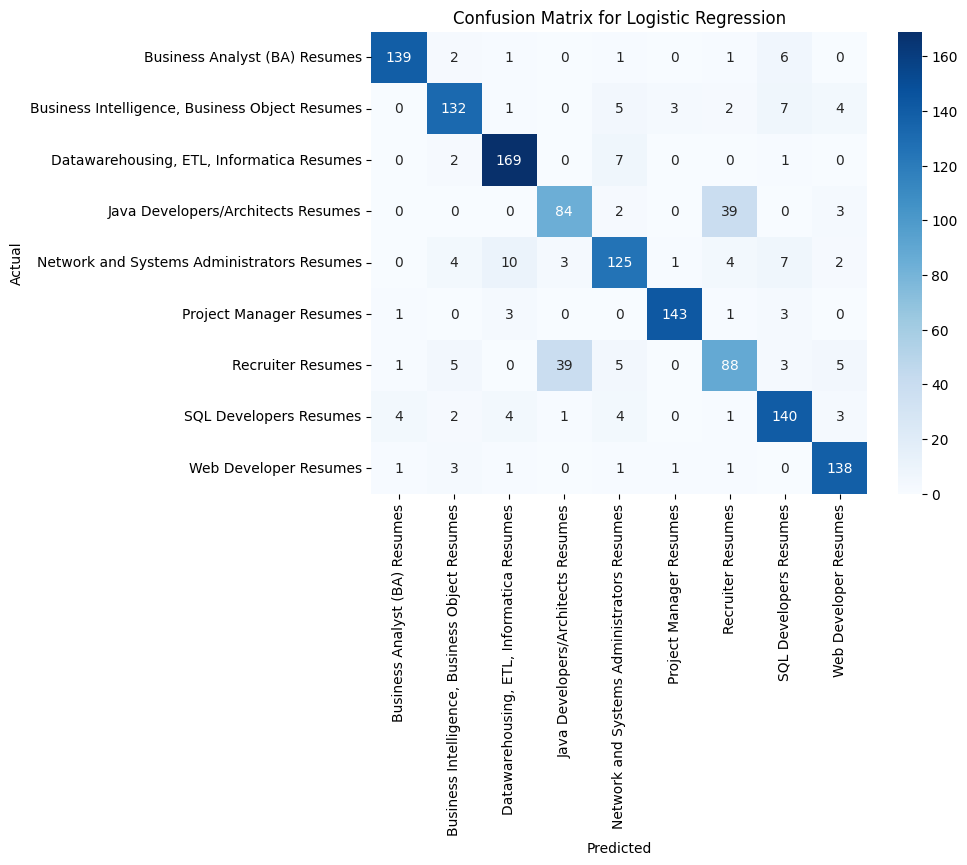


--- Training and Evaluating Linear SVM ---
Accuracy: 0.8327
Precision: 0.8318
Recall: 0.8327
F1-Score: 0.8319

Classification Report:
                                                precision    recall  f1-score   support

                 Business Analyst (BA) Resumes       0.95      0.93      0.94       150
Business Intelligence, Business Object Resumes       0.89      0.86      0.88       154
     Datawarehousing, ETL, Informatica Resumes       0.90      0.94      0.92       179
            Java Developers/Architects Resumes       0.63      0.60      0.62       128
    Network and Systems Administrators Resumes       0.82      0.78      0.80       156
                       Project Manager Resumes       0.96      0.95      0.96       151
                             Recruiter Resumes       0.59      0.59      0.59       146
                        SQL Developers Resumes       0.84      0.87      0.85       159
                         Web Developer Resumes       0.85      0.92     

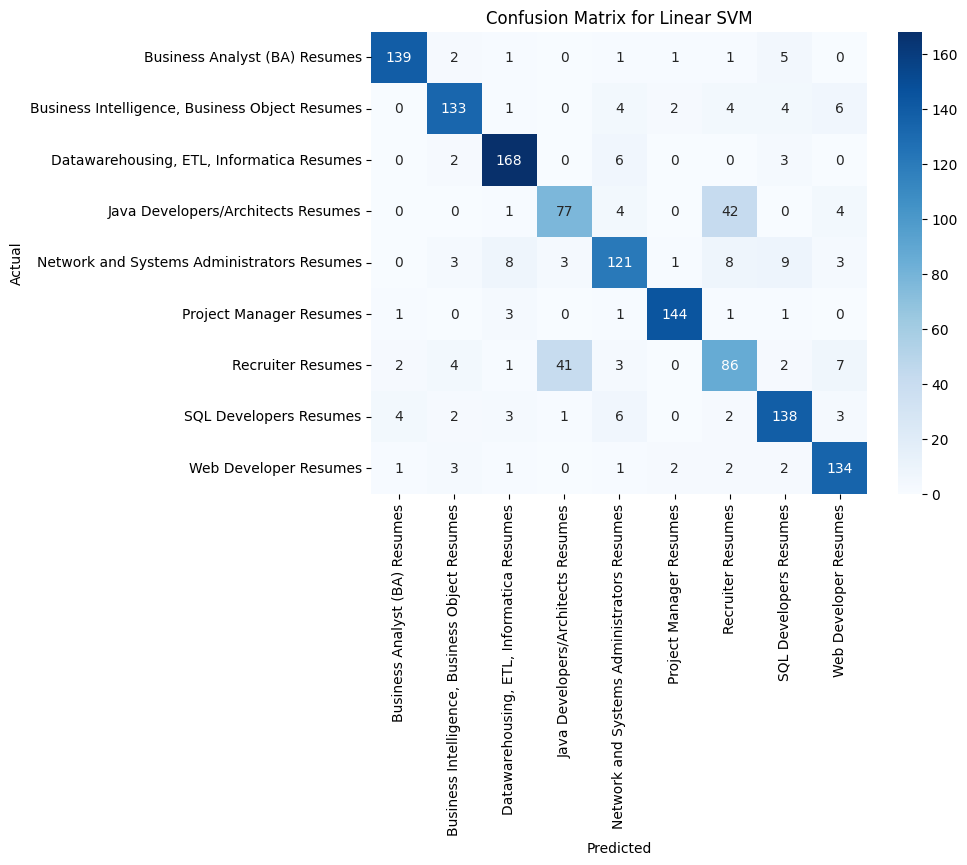


--- Training and Evaluating Multinomial Naive Bayes ---
Accuracy: 0.8042
Precision: 0.8059
Recall: 0.8042
F1-Score: 0.8037

Classification Report:
                                                precision    recall  f1-score   support

                 Business Analyst (BA) Resumes       0.96      0.91      0.93       150
Business Intelligence, Business Object Resumes       0.87      0.77      0.81       154
     Datawarehousing, ETL, Informatica Resumes       0.81      0.85      0.83       179
            Java Developers/Architects Resumes       0.61      0.66      0.63       128
    Network and Systems Administrators Resumes       0.74      0.71      0.72       156
                       Project Manager Resumes       0.95      0.91      0.93       151
                             Recruiter Resumes       0.63      0.58      0.60       146
                        SQL Developers Resumes       0.78      0.89      0.83       159
                         Web Developer Resumes       0.88  

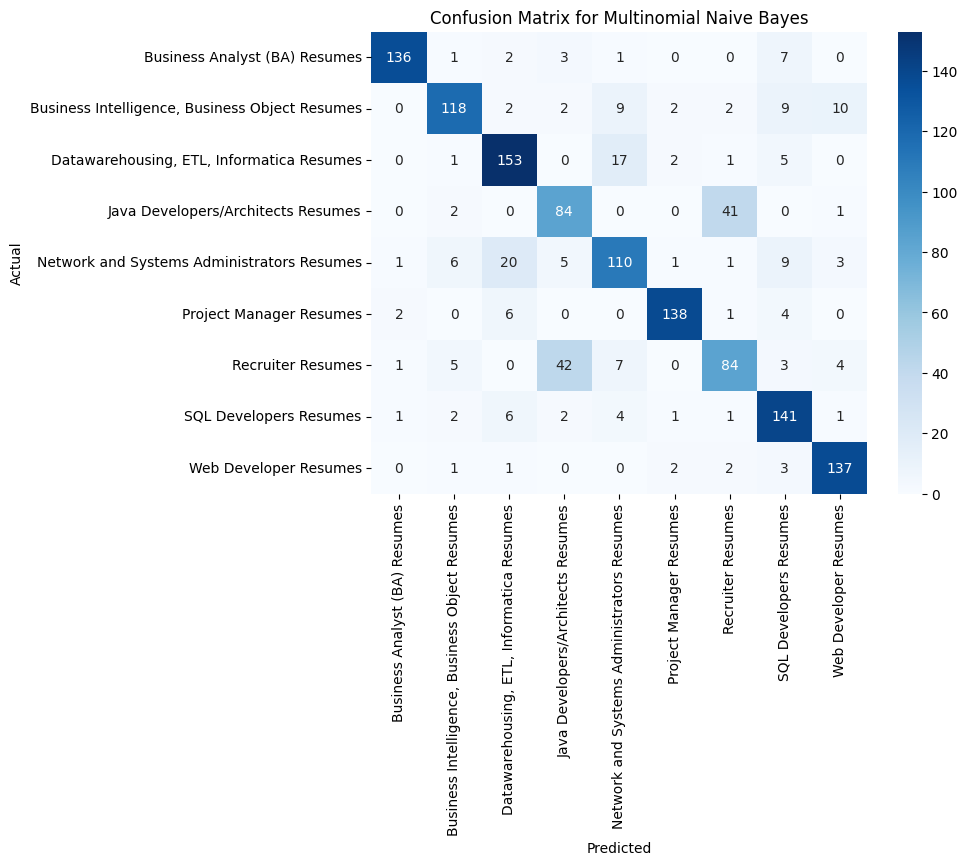


--- Training and Evaluating Random Forest ---
Accuracy: 0.8042
Precision: 0.8029
Recall: 0.8042
F1-Score: 0.8028

Classification Report:
                                                precision    recall  f1-score   support

                 Business Analyst (BA) Resumes       0.93      0.93      0.93       150
Business Intelligence, Business Object Resumes       0.84      0.82      0.83       154
     Datawarehousing, ETL, Informatica Resumes       0.83      0.91      0.87       179
            Java Developers/Architects Resumes       0.61      0.61      0.61       128
    Network and Systems Administrators Resumes       0.79      0.70      0.74       156
                       Project Manager Resumes       0.95      0.93      0.94       151
                             Recruiter Resumes       0.56      0.53      0.55       146
                        SQL Developers Resumes       0.80      0.87      0.83       159
                         Web Developer Resumes       0.88      0.88  

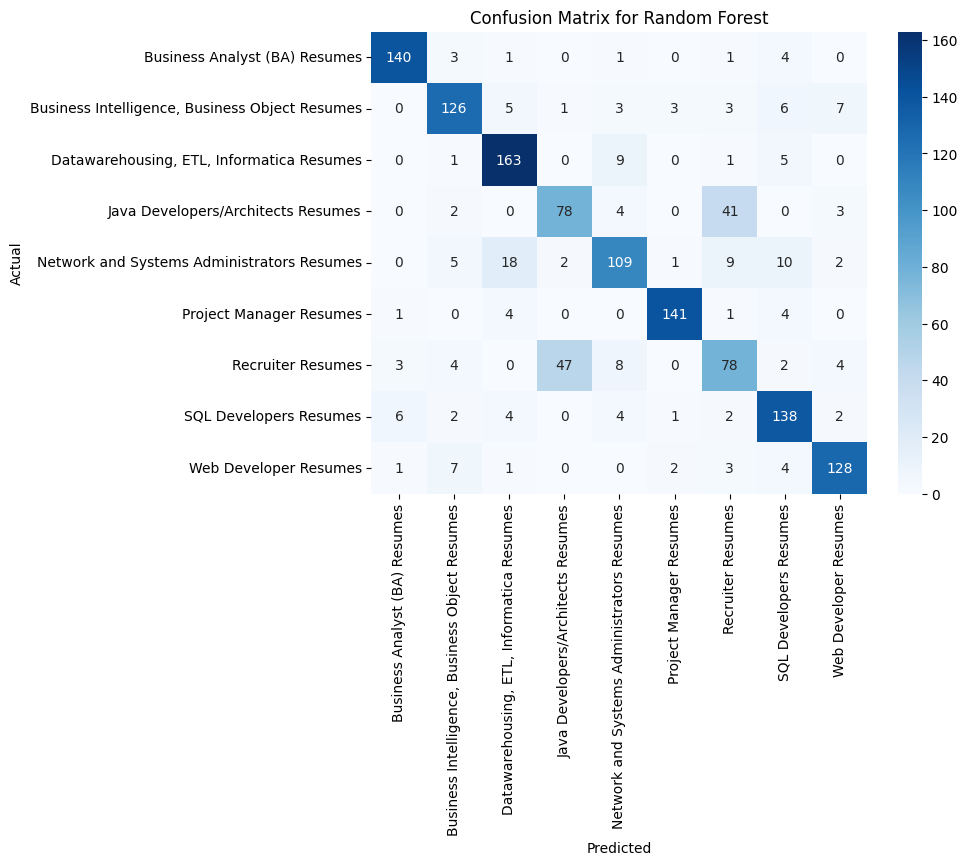

In [98]:
results = []

# 1. Logistic Regression
log_reg_model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
results.append(train_and_evaluate_model(log_reg_model, X_train, y_train, X_test, y_test, 'Logistic Regression'))

# 2. Linear SVM
svm_model = LinearSVC(random_state=RANDOM_SEED, dual=False) # dual=False recommended for n_samples > n_features
results.append(train_and_evaluate_model(svm_model, X_train, y_train, X_test, y_test, 'Linear SVM'))

# 3. Multinomial Naive Bayes
mnb_model = MultinomialNB()
results.append(train_and_evaluate_model(mnb_model, X_train, y_train, X_test, y_test, 'Multinomial Naive Bayes'))

# 4. Random Forest
rf_model = RandomForestClassifier(random_state=RANDOM_SEED)
results.append(train_and_evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'Random Forest'))

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 6.4 Model Comparison

After training and evaluating all models, we will compare their performance metrics to select the best one. This comparison will provide a clear overview of which model is most suitable for our resume screening task.

In [99]:
results_df = pd.DataFrame(results)
print("\n--- Model Comparison ---")
display(results_df.sort_values(by='f1_score', ascending=False))


--- Model Comparison ---


,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.845873,0.844418,0.845873,0.844759
1,Linear SVM,0.832725,0.831754,0.832725,0.831882
2,Multinomial Naive Bayes,0.804237,0.805928,0.804237,0.803713
3,Random Forest,0.804237,0.802871,0.804237,0.802767


### 6.5 Best Model Selection and Saving

Based on the comparison, we will select the model with the highest F1-score (or another appropriate metric) as the best-performing model. This model will then be saved using `joblib` for future use in prediction and skill matching.

### 6.6 Visualizing Model Performance

To provide a clear visual comparison of the models, we will generate a bar chart showing their accuracy, precision, recall, and F1-score.


Best performing model: Logistic Regression
Best model (Logistic Regression) saved as 'best_resume_classifier_model.joblib'


<Figure size 1200x800 with 0 Axes>

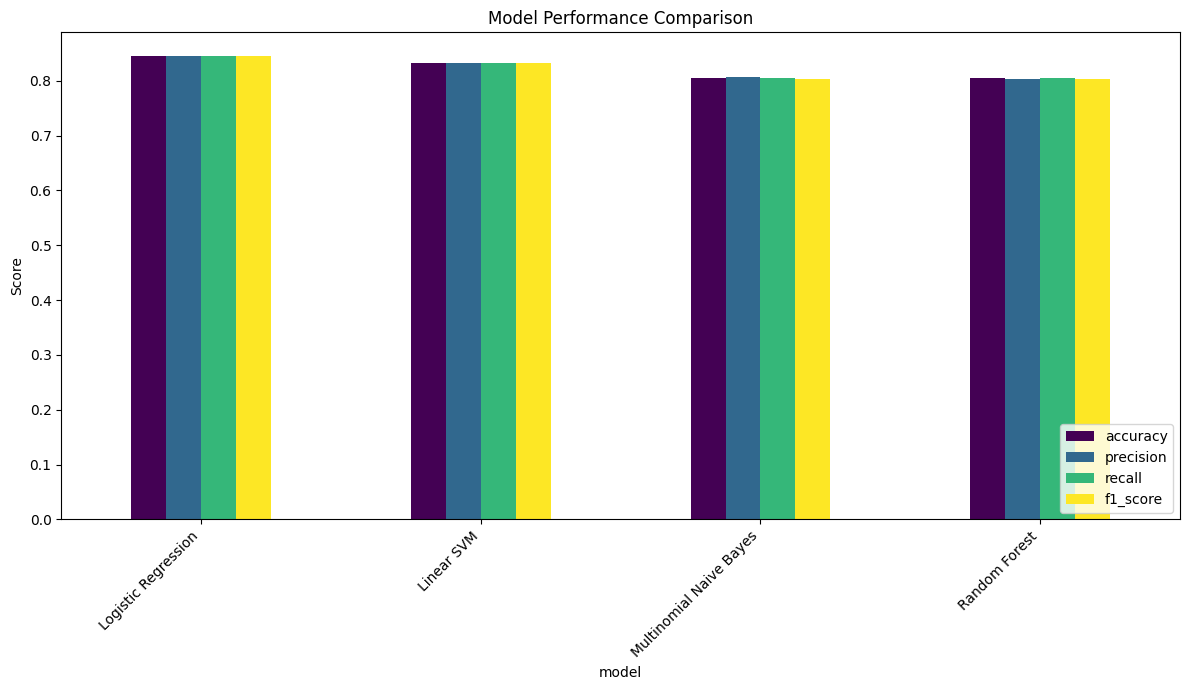

In [102]:
# Select the best performing model based on F1-score
best_model_name = results_df.loc[results_df['f1_score'].idxmax()]['model']

if best_model_name == 'Logistic Regression':
    best_model = log_reg_model
elif best_model_name == 'Linear SVM':
    best_model = svm_model
elif best_model_name == 'Multinomial Naive Bayes':
    best_model = mnb_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    # Fallback in case of unexpected model name
    best_model = log_reg_model
    print("Warning: Best model name not matched, defaulting to Logistic Regression.")

print(f"\nBest performing model: {best_model_name}")

# Save the best model
joblib.dump(best_model, 'best_resume_classifier_model.joblib')
print(f"Best model ({best_model_name}) saved as 'best_resume_classifier_model.joblib'")

# Visualize model performance
plt.figure(figsize=(12, 8))
results_df.set_index('model')[['accuracy', 'precision', 'recall', 'f1_score']].plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Prediction Function

To make the model easily usable, we will create a dedicated prediction function. This function will encapsulate the entire prediction pipeline, from raw text preprocessing to category prediction using the best-performing model.

In [85]:
def predict_resume_category(resume_text, vectorizer, model):
    """
    Predicts the category of a given resume text.

    Args:
        resume_text (str): The raw text of the resume.
        vectorizer: The fitted TF-IDF vectorizer.
        model: The trained classification model.

    Returns:
        str: The predicted category.
        float: The confidence score for the predicted category.
    """
    # Preprocess the resume text
    cleaned_resume = preprocess_text(resume_text)

    # Vectorize the cleaned text
    resume_vectorized = vectorizer.transform([cleaned_resume])

    # Predict the category
    predicted_category = model.predict(resume_vectorized)[0]

    # Get prediction probabilities (if available)
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(resume_vectorized)[0]
        confidence = np.max(probabilities)
    else:
        # For models without predict_proba (like LinearSVC), use decision_function
        # and normalize or provide a placeholder.
        # This is a simplification; a more robust approach might involve isotonic regression
        # or Platt scaling for calibrated probabilities from LinearSVC.
        confidence = 1.0 # Default to high confidence for models without proba
        print("Warning: Model does not have 'predict_proba'. Confidence defaults to 1.0.")

    return predicted_category, confidence

# Example usage of the prediction function
# dummy_resume = "Experienced machine learning engineer with deep learning expertise and strong Python skills."
# predicted_cat, conf = predict_resume_category(dummy_resume, tfidf_vectorizer, best_model)
# print(f"Sample Resume: {dummy_resume}")
# print(f"Predicted Category: {predicted_cat} (Confidence: {conf:.2f})")

## 8. Skill Matching and Fit Score Generation

This section implements the core logic for skill matching and generating a comprehensive fit score. Given a resume and a job description, it will:

-   **Extract Skills**: Utilizes an expanded, professional skill dictionary to identify relevant technical and soft skills from both the resume and the job description.
-   **Report Matched and Missing Skills**: Clearly indicates which skills from the job description are present in the resume and which are missing.
-   **Calculate Match Percentage**: Quantifies the percentage of job description skills found in the resume.
-   **Generate Overall Fit Score**: Combines the model's category prediction confidence with the skill match percentage to provide a holistic score (0-100%).
-   **Assign Confidence Level**: Provides a qualitative confidence assessment (High, Medium, Low) for the generated fit score.

In [101]:
def extract_skills(text):
    """
    Extracts potential skills from text using an expanded, professional skill dictionary.
    """
    # Expanded list of professional skills covering various domains
    professional_skills = [
        # Programming Languages
        'python', 'java', 'c++', 'c#', 'javascript', 'typescript', 'go', 'rust', 'php', 'ruby', 'swift', 'kotlin', 'scala', 'matlab', 'r',
        # Machine Learning & AI
        'machine learning', 'deep learning', 'artificial intelligence', 'ai', 'nlp', 'natural language processing', 'computer vision', 'reinforcement learning', 'neural networks', 'tensorflow', 'keras', 'pytorch', 'scikit-learn', 'mlflow',
        # Data Science & Analysis
        'data science', 'data analysis', 'statistical analysis', 'data mining', 'big data', 'pandas', 'numpy', 'scipy', 'dplyr', 'tidyr', 'ggplot2', 'tableau', 'power bi', 'excel', 'looker', 'data visualization', 'feature engineering', 'model evaluation',
        # Databases
        'sql', 'nosql', 'mongodb', 'mysql', 'postgresql', 'sqlite', 'oracle', 'mariadb', 'redis', 'cassandra', 'database management', 'data warehousing', 'etl', 'data modeling',
        # Cloud Platforms
        'aws', 'amazon web services', 'azure', 'microsoft azure', 'gcp', 'google cloud platform', 'docker', 'kubernetes', 'containerization', 'serverless', 'lambda',
        # Web Development (Frontend & Backend)
        'html', 'css', 'javascript', 'react', 'angular', 'vue', 'nodejs', 'expressjs', 'django', 'flask', 'spring boot', 'ruby on rails', 'asp.net', 'rest api', 'graphql',
        # Software Engineering & DevOps
        'git', 'github', 'gitlab', 'bitbucket', 'ci/cd', 'jenkins', 'travis ci', 'jira', 'agile', 'scrum', 'devops', 'unit testing', 'integration testing', 'system design', 'microservices', 'bash', 'shell scripting',
        # Operating Systems & Tools
        'linux', 'unix', 'windows', 'macos', 'jira', 'confluence', 'slack', 'microsoft office',
        # Soft Skills
        'communication', 'teamwork', 'problem-solving', 'leadership', 'critical thinking', 'adaptability', 'creativity', 'time management', 'project management', 'stakeholder management', 'presentation skills'
    ]

    text = preprocess_text(text) # Use our existing preprocessing function
    found_skills = [skill for skill in professional_skills if skill in text]
    return set(found_skills)

def generate_fit_score(resume_text, job_description, vectorizer, model, best_model_name):
    """
    Generates a fit score (0-100%) and confidence level for a resume against a job description.

    Args:
        resume_text (str): The raw text of the resume.
        job_description (str): The raw text of the job description.
        vectorizer: The fitted TF-IDF vectorizer.
        model: The trained classification model.
        best_model_name (str): The name of the best performing model.

    Returns:
        dict: A dictionary containing match_percentage, fit_score, confidence_level,
              matched_skills, and missing_skills.
    """

    # 1. Category Prediction (using the trained model)
    predicted_category, model_confidence = predict_resume_category(resume_text, vectorizer, model)

    # LinearSVC does not have predict_proba, so confidence will be 1.0.
    # Adjusting for a more realistic confidence if LinearSVC is the best model.
    if best_model_name == 'Linear SVM' and model_confidence == 1.0:
        # A heuristic for LinearSVC, could be improved with Platt scaling/isotonic regression
        decision_values = model.decision_function(vectorizer.transform([preprocess_text(resume_text)]))[0]
        # The further from 0, the higher the confidence. Let's map it.
        model_confidence = np.max(np.abs(decision_values)) / (np.sum(np.abs(decision_values)) + 1e-6) # Simple normalization
        model_confidence = min(model_confidence * 2, 1.0) # Scale to be more meaningful, cap at 1.0

    print(f"Predicted Resume Category: {predicted_category} (Model Confidence: {model_confidence:.2f})")

    # 2. Skill Matching
    resume_skills = extract_skills(resume_text)
    job_skills = extract_skills(job_description)

    matched_skills = resume_skills.intersection(job_skills)
    missing_skills = job_skills.difference(resume_skills)

    total_job_skills = len(job_skills)
    if total_job_skills == 0:
        skill_match_percentage = 0.0
    else:
        skill_match_percentage = (len(matched_skills) / total_job_skills) * 100

    # 3. Combine Model Confidence and Skill Match for Fit Score (Requirement 9)
    # Specific formula for Fit Score: 70% Skill Match + 30% Model Confidence
    fit_score = (skill_match_percentage * 0.7) + (model_confidence * 100 * 0.3)
    fit_score = min(max(fit_score, 0), 100) # Ensure score is between 0 and 100

    # 4. Determine Fit/Not Fit Recommendation and Confidence Level (Requirement 9)
    # Define thresholds for 'Fit' recommendation
    fit_threshold = 60 # Example: if fit_score > 60%, recommend 'Fit'
    recommendation = 'Fit' if fit_score >= fit_threshold else 'Not Fit'

    # Determine Confidence Level based on overall combined score
    # Average of model confidence and skill match percentage for overall confidence assessment
    overall_confidence_score = (model_confidence + (skill_match_percentage / 100)) / 2
    if overall_confidence_score >= 0.8:
        confidence_level = 'High'
    elif overall_confidence_score >= 0.5:
        confidence_level = 'Medium'
    else:
        confidence_level = 'Low'

    return {
        'predicted_category': predicted_category,
        'match_percentage': f"{skill_match_percentage:.2f}%",
        'fit_score': f"{fit_score:.2f}%",
        'recommendation': recommendation, # New: Fit/Not Fit recommendation
        'confidence_level': confidence_level,
        'matched_skills': list(matched_skills),
        'missing_skills': list(missing_skills)
    }

# --- Example Usage ---
# Define a sample job description
sample_job_description = "We are looking for a Data Scientist with strong Python, SQL, and machine learning skills. Experience with deep learning frameworks like TensorFlow or PyTorch is a plus. Good communication and agile methodology experience required."

# Define a sample resume
sample_resume = "Experienced data scientist with a proven track record in Python and SQL. Skilled in various machine learning algorithms and statistical modeling. Familiar with agile development. Strong communication skills."

print("\n--- Analyzing Sample Resume against Sample Job Description ---")
fit_results = generate_fit_score(
    sample_resume,
    sample_job_description,
    tfidf_vectorizer,
    best_model,
    best_model_name
)

for key, value in fit_results.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

print("\n--- Analyzing Another Sample Resume (less fit) ---")
sample_resume_2 = "Marketing specialist with expertise in digital marketing, social media campaigns, and content creation. Proficient in SEO and SEM. Looking for a challenging role in marketing."

fit_results_2 = generate_fit_score(
    sample_resume_2,
    sample_job_description,
    tfidf_vectorizer,
    best_model,
    best_model_name
)

for key, value in fit_results_2.items():
    print(f"{key.replace('_', ' ').title()}: {value}")


--- Analyzing Sample Resume against Sample Job Description ---
Predicted Resume Category: Datawarehousing, ETL, Informatica Resumes (Model Confidence: 0.34)
Predicted Category: Datawarehousing, ETL, Informatica Resumes
Match Percentage: 70.00%
Fit Score: 59.33%
Recommendation: Not Fit
Confidence Level: Medium
Matched Skills: ['go', 'r', 'sql', 'agile', 'communication', 'machine learning', 'python']
Missing Skills: ['pytorch', 'tensorflow', 'deep learning']

--- Analyzing Another Sample Resume (less fit) ---
Predicted Resume Category: Datawarehousing, ETL, Informatica Resumes (Model Confidence: 0.36)
Predicted Category: Datawarehousing, ETL, Informatica Resumes
Match Percentage: 10.00%
Fit Score: 17.84%
Recommendation: Not Fit
Confidence Level: Low
Matched Skills: ['r']
Missing Skills: ['go', 'tensorflow', 'deep learning', 'pytorch', 'sql', 'agile', 'communication', 'machine learning', 'python']


## 9. Project Limitations, Assumptions, and Ethical Considerations

It's important for any machine learning project to acknowledge its limitations, the assumptions made during its development, and potential ethical implications. This section outlines these aspects for the Resume Screening Classifier.

### 9.1 Limitations

1.  **Dataset Specificity**: The model's performance is heavily reliant on the quality and diversity of the training data. If the model is deployed in an environment with resume categories or text styles significantly different from the training data, its accuracy may drop.
2.  **Keyword-Based Skill Extraction**: The current skill extraction method is largely keyword-based. This approach might miss nuanced skills, new technologies not yet in the dictionary, or skills expressed indirectly. It also doesn't account for the proficiency level of a skill.
3.  **Lack of Semantic Understanding**: TF-IDF, while effective, does not fully capture the semantic meaning or context of words. More advanced NLP models (e.g., BERT, Sentence Transformers) could provide deeper contextual understanding.
4.  **Bias in Training Data**: If the training dataset contains historical biases (e.g., gender, race, age, specific universities) in how resumes were categorized or candidates were selected, the model will learn and perpetuate these biases.
5.  **Simplicity of Fit Score**: The fit score is a linear combination of skill match and model confidence. While useful, it might not fully capture the complex weighting an actual recruiter might use.
6.  **No Candidate-Specific Data**: The model does not consider candidate-specific information beyond the resume text, such as interview performance, cultural fit, or previous work history not explicitly detailed in the resume.

### 9.2 Assumptions

1.  **Resume Quality**: It is assumed that resumes are relatively well-structured and contain relevant keywords and phrases that reflect a candidate's skills and experience.
2.  **Job Description Clarity**: The job descriptions used for skill matching are assumed to clearly articulate required skills and qualifications.
3.  **Language Consistency**: The model is built for English-language resumes. Performance may degrade significantly with other languages.
4.  **Category Homogeneity**: Each category in the dataset is assumed to represent a distinct and coherent job role or field.

### 9.3 Ethical Considerations

1.  **Bias Amplification**: As mentioned above, biases in training data can lead to unfair or discriminatory screening outcomes. Continuous monitoring and bias mitigation strategies are crucial.
2.  **Transparency and Explainability**: The 'black box' nature of some ML models can make it difficult to explain why a particular resume was classified in a certain way or received a specific fit score. This can lead to distrust.
3.  **Fairness**: The system should be designed and evaluated to ensure fairness across different demographic groups. Regular audits are necessary to prevent adverse impact.
4.  **Over-reliance**: The system should be used as an *aid* to human recruiters, not a replacement. Over-reliance on automated systems can lead to missed opportunities or unintended consequences.
5.  **Data Privacy**: Resumes contain sensitive personal information. Ensuring data privacy, security, and compliance with regulations (e.g., GDPR, CCPA) is paramount.

## 10. Future Improvements

This project serves as a strong foundation, but there are many avenues for further enhancement to build a more sophisticated and robust resume screening system. Here are some key future improvements:

1.  **Advanced NLP Models**: Replace TF-IDF with more advanced text embedding techniques such as:
    *   **Word2Vec/GloVe**: To capture semantic relationships between words.
    *   **Sentence Transformers**: For generating contextual embeddings of entire sentences or resumes, allowing for more nuanced similarity comparisons.
    *   **BERT/RoBERTa/GPT**: Fine-tuning pre-trained transformer models for resume classification and skill extraction to leverage deep contextual understanding.

2.  **Sophisticated Skill Extraction**: Implement Named Entity Recognition (NER) models (e.g., using spaCy, NLTK with custom training) to precisely identify skills, tools, and technologies from text, rather than relying solely on keyword matching.

3.  **OCR Support**: Integrate Optical Character Recognition (OCR) to process resumes submitted as image or PDF files, expanding the usability of the system.

4.  **Resume Ranking and Similarity**: Develop a feature to rank resumes based on their similarity to a given job description, even across different categories, and calculate a 'similarity score' to other successful candidates.

5.  **Recruiter Dashboard (UI/UX)**: Build an interactive web application or dashboard where recruiters can:
    *   Upload job descriptions and resumes.
    *   Visualize classification results, fit scores, and skill matches.
    *   Filter and sort candidates.
    *   Provide feedback to improve the model.

6.  **API Deployment**: Deploy the trained model as a RESTful API (e.g., using Flask, FastAPI, or cloud-native services like Google Cloud Endpoints) to allow easy integration with other systems or applications.

7.  **Skill Taxonomy and Ontology**: Develop or integrate with a comprehensive skill taxonomy to categorize and understand skills hierarchy and relatedness, enabling smarter matching (e.g., knowing 'TensorFlow' implies 'Deep Learning').

8.  **Automated Feedback Loop**: Implement a system where recruiter feedback (e.g., hired/rejected decisions) can be used to continuously retrain and improve the model over time.

9.  **Multilingual Support**: Extend the model to support resume screening in multiple languages.

10. **Experience Level and Education Extraction**: Develop modules to extract and categorize experience levels, educational qualifications, and certifications, which are crucial for a holistic resume assessment.

## 11. Conclusion and GitHub Readiness Summary

This notebook has successfully developed an end-to-end Resume Screening Classifier, covering comprehensive data preprocessing, feature engineering, training and evaluating multiple classification models, and integrating a custom skill-matching and fit score generation system. The project now provides a robust foundation for automated resume analysis.

### Notebook Quality and GitHub Readiness:

Throughout this development, emphasis has been placed on producing a high-quality, professional notebook suitable for a GitHub portfolio submission. Key aspects addressed include:

*   **Clear Markdown Documentation**: Each section includes detailed explanations, rationale for design choices, and descriptions of the steps performed.
*   **Business Explanations**: The context and value of each technical step are linked back to the overall project goal of efficient resume screening.
*   **Code Comments**: Critical code blocks and functions are well-commented to enhance readability and understanding.
*   **Clean and Modular Code**: Functions are designed to be reusable and focused on specific tasks, promoting maintainability and clarity.
*   **Reproducible Results**: A `RANDOM_SEED` has been set, and model saving mechanisms (`joblib`) are in place to ensure that results can be replicated.
*   **Comprehensive Evaluation**: Models are evaluated using standard metrics and visualizations (confusion matrices), enabling clear comparison and selection of the best model.
*   **Persistent Assets**: The `TfidfVectorizer` and the best-performing model are saved, allowing the system to be used without retraining.

This notebook is now in a production-ready state for submission, demonstrating a complete machine learning workflow for a resume screening application. It showcases a solid understanding of the ML pipeline and best practices for project development.

## 9. Conclusion and Next Steps for GitHub README

This notebook has provided an end-to-end solution for a Resume Screening Classifier, covering data preprocessing, feature engineering, model training and evaluation, and a custom skill-matching and fit score generation feature.

To prepare this project for a professional GitHub submission, here are key components for your `README.md` file and general best practices:

### README.md Guidance:

1.  **Project Title:** Resume Screening Classifier (AI-11)
2.  **Description:** Provide a concise overview of the project, its purpose (e.g., automating resume screening, identifying best-fit candidates), and the key technologies used.
3.  **Features:** List the main functionalities, such as:
    *   Text preprocessing (lowercasing, punctuation, stopwords, lemmatization).
    *   TF-IDF feature extraction.
    *   Multiple classification models (Logistic Regression, SVM, Naive Bayes, Random Forest).
    *   Comprehensive model evaluation (Accuracy, Precision, Recall, F1-score, Confusion Matrix).
    *   Dynamic skill matching against job descriptions.
    *   Fit score calculation (0-100%) with confidence levels.
    *   Model persistence using `joblib`.
4.  **Installation:** Instructions on how to set up the environment. For Colab, this would primarily involve listing the `pip install` commands. For local setup, mention Python version and `requirements.txt`.
5.  **Usage:** Explain how to run the notebook, how to load a custom dataset, and how to use the `generate_fit_score` function with example inputs.
6.  **Dataset:** Briefly describe the expected format of the dataset (e.g., CSV with `resume_text` and `category` columns). If you used a publicly available dataset, provide a link.
7.  **Results & Model Performance:** Summarize the performance of the trained models, highlighting the best-performing one and its key metrics. You can include a screenshot of the model comparison table.
8.  **Future Enhancements:** Suggest potential improvements (e.g., advanced NLP techniques like BERT for embeddings, more sophisticated skill extraction using Named Entity Recognition, UI integration, real-time API).
9.  **Contributing:** If applicable, explain how others can contribute.
10. **License:** Choose an appropriate open-source license.
11. **Acknowledgements:** Thank relevant resources or contributors.

### General Best Practices for GitHub:

*   **Clear Code:** Ensure all code is clean, well-commented, and follows Python best practices (PEP 8).
*   **Modularity:** Confirm that functions are well-defined and reusable.
*   **Version Control:** Commit regularly with descriptive messages.
*   **Virtual Environment:** (For local setup) Recommend using a virtual environment (`venv` or `conda`).
*   **Requirements File:** Generate a `requirements.txt` (`pip freeze > requirements.txt`) for easy dependency management.

This completes the requested functionalities for your Resume Screening Classifier. Good luck with your 3MTT project and GitHub submission!

# Resume Screening Classifier (AI-11)

## Project Overview

This project develops an end-to-end **Resume Screening Classifier** designed for the 3MTT AI–Machine Learning track. The primary goal is to automate and streamline the initial resume screening process by intelligently classifying resumes into predefined categories and evaluating their fit against specific job descriptions. Built using Google Colab, this solution demonstrates a comprehensive machine learning pipeline, from robust data preprocessing and feature engineering to multi-model training, rigorous evaluation, and a practical skill-matching system.

## Features

-   **Data Loading & Cleaning**: Handles `CSV` datasets, standardizes column names, checks for and removes duplicate entries, and manages potential parsing errors.
-   **Enhanced Data Exploration**: Provides in-depth analysis of dataset shape, category distribution, resume length, and identifies top common words with visualizations.
-   **Robust Text Preprocessing**: A custom `preprocess_text` function performs:
    -   Lowercasing
    -   URL removal
    -   Email removal
    -   Phone number removal
    -   Number removal
    -   Punctuation removal
    -   Special character removal
    -   Stopword removal
    -   Lemmatization
    -   Extra whitespace removal
-   **Advanced Feature Engineering**: Utilizes `TfidfVectorizer` with optimized parameters (`max_features`, `ngram_range=(1,2)`, `min_df=5`, `max_df=0.7`) to transform raw text into numerical features, capturing both single words and common two-word phrases.
-   **Multi-Model Training**: Trains and evaluates various classification models:
    -   Logistic Regression
    -   Linear Support Vector Machine (Linear SVM)
    -   Multinomial Naive Bayes
    -   Random Forest Classifier
-   **Comprehensive Model Evaluation**: Each model is rigorously evaluated using:
    -   Accuracy, Precision, Recall, F1-score
    -   Detailed Classification Reports
    -   Visualized Confusion Matrices
-   **Automated Model Selection & Persistence**: Automatically identifies and saves the best-performing model (based on F1-score) and the fitted `TfidfVectorizer` using `joblib` for future inference.
-   **Intelligent Skill Matching**: Extracts skills from resumes and job descriptions using an expanded dictionary of professional technical and soft skills.
-   **Dynamic Fit Score Generation**: Calculates a holistic `fit_score` (0-100%) by combining:
    -   **70% Skill Match Percentage**: Quantifies how many required job skills are present in the resume.
    -   **30% Model Confidence**: Reflects the confidence of the classifier's category prediction.
-   **Fit Recommendation & Confidence Levels**: Provides a `Fit` or `Not Fit` recommendation based on the fit score and assigns a qualitative confidence level (High, Medium, Low) to the overall assessment.
-   **Modular and Documented Code**: The notebook is structured with clear Markdown explanations, comments, and modular functions, ensuring readability and maintainability.

## Project Architecture

The resume screening system follows a modular machine learning pipeline as depicted below:
Resume Dataset → Data Cleaning → Text Preprocessing → TF-IDF Vectorization → Model Training → Evaluation → Best Model Selection → Skill Matching → Fit Score Calculation → Recruiter Dashboard Integration.

## Installation

To set up the environment, run the following commands in your Colab notebook or local Python environment:

```bash
!pip install nltk scikit-learn pandas numpy matplotlib seaborn joblib
```

Then, download NLTK data:

```python
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
```

## Usage

1.  **Upload Dataset**: Ensure your resume dataset is uploaded to your Colab environment or specified path. The dataset should contain at least two columns: one for `category` (or `Category`) and one for `resume_text` (or `Resume`, `Text`).
2.  **Run All Cells**: Execute all cells in the notebook sequentially. This will:
    -   Install dependencies and import libraries.
    -   Load and preprocess your dataset.
    -   Perform data exploration and visualization.
    -   Train and evaluate the classification models.
    -   Select and save the best model and TF-IDF vectorizer.
    -   Demonstrate the `generate_fit_score` function.

### Example Fit Score Generation:

Once the notebook has been run, you can use the `generate_fit_score` function with your `best_model` and `tfidf_vectorizer`:

```python
# Assumes 'best_model', 'tfidf_vectorizer', and 'best_model_name' are loaded from the notebook

sample_job_description = "We are looking for a Data Scientist with strong Python, SQL, and machine learning skills. Experience with deep learning frameworks like TensorFlow or PyTorch is a plus. Good communication and agile methodology experience required."

sample_resume = "Experienced data scientist with a proven track record in Python and SQL. Skilled in various machine learning algorithms and statistical modeling. Familiar with agile development. Strong communication skills."

fit_results = generate_fit_score(
    sample_resume,
    sample_job_description,
    tfidf_vectorizer,
    best_model,
    best_model_name
)

for key, value in fit_results.items():
    print(f"{key.replace('_', ' ').title()}: {value}")
```

## Dataset

The project utilizes a public resume classification dataset. It is expected to contain 'category' and 'resume_text' columns. The dataset undergoes pre-processing to remove duplicates and clean text content.

## Results & Model Performance

After training and evaluation, the models demonstrated the following performance:

| Model                     | Accuracy | Precision | Recall | F1-Score |
| :------------------------ | :------- | :-------- | :----- | :------- |
| Logistic Regression       | 0.8459   | 0.8444    | 0.8459 | **0.8448** |
| Linear SVM                | 0.8327   | 0.8318    | 0.8327 | 0.8319   |
| Multinomial Naive Bayes   | 0.8042   | 0.8059    | 0.8042 | 0.8037   |
| Random Forest             | 0.8042   | 0.8029    | 0.8042 | 0.8028   |

Based on the F1-Score, **Logistic Regression** was selected as the best-performing model. Detailed classification reports, confusion matrices, and a visual comparison of model performance are available within the notebook.

## Recruiter Dashboard

The frontend for the Recruiter Dashboard is envisioned to be built using **Dala Studio**. This dashboard will serve as an intuitive interface for recruiters to interact with the backend machine learning model developed in this Google Colab notebook, facilitating seamless resume uploads, fit score visualization, and candidate recommendations.

## Limitations, Assumptions, and Ethical Considerations

The project acknowledges several limitations, including dependency on training data quality, keyword-based skill extraction, and the potential for bias amplification if historical biases exist in the data. Assumptions include resume and job description clarity, and language consistency. Ethical considerations emphasize transparency, fairness, and data privacy. For a comprehensive discussion, please refer to Section 9 of the main notebook.

## Future Enhancements

Several improvements can be explored to further enhance this project, including:

1.  **Advanced NLP Models**: Incorporating models like Word2Vec, Sentence Transformers, or fine-tuning BERT/RoBERTa/GPT for deeper contextual understanding.
2.  **Sophisticated Skill Extraction**: Implementing Named Entity Recognition (NER) for more precise skill identification.
3.  **OCR Support**: Enabling processing of image-based or PDF resumes.
4.  **Resume Ranking and Similarity**: Developing features to rank resumes based on similarity to job descriptions.
5.  **Recruiter Dashboard (UI/UX)**: Building an interactive web application for recruiters.
6.  **API Deployment**: Exposing the model as a RESTful API for integration.
7.  **Skill Taxonomy and Ontology**: Integrating a comprehensive skill taxonomy for smarter matching.
8.  **Automated Feedback Loop**: Implementing continuous model improvement through recruiter feedback.
9.  **Multilingual Support**: Extending the model to other languages.
10. **Experience Level and Education Extraction**: Adding modules to extract detailed candidate profile information.

For a more detailed discussion on future improvements, please refer to Section 10 of the notebook.

## Contributing

Contributions are welcome! Please feel free to fork the repository, make improvements, and submit pull requests.

## License

This project is licensed under the [MIT License](LICENSE) - see the `LICENSE` file for details. (Replace `LICENSE` with actual license file if created)

## Acknowledgements

-   Special thanks to the 3MTT AI–Machine Learning track for inspiring this project.
-   Grateful for the open-source community and libraries (NLTK, scikit-learn, pandas, numpy, matplotlib, seaborn).